<a href="https://colab.research.google.com/github/ahmedelgaib/Cnn-project/blob/main/project_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gradio

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),


    layers.Flatten(),
    layers.Dense(64, activation='relu'),


    layers.Dense(3, activation='softmax')
])

In [4]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [5]:
import cv2
import random

def create_data(num_samples=1000):
    images = []
    labels = []
    for i in range(num_samples):

        img_circle = np.zeros((64, 64, 3), np.uint8)
        img_square = np.zeros((64, 64, 3), np.uint8)
        img_tri = np.zeros((64, 64, 3), np.uint8)


        cv2.circle(img_circle, (32, 32), random.randint(10, 25), (255, 255, 255), -1)
        images.append(img_circle)
        labels.append(0)


        cv2.rectangle(img_square, (15, 15), (50, 50), (255, 255, 255), -1)
        images.append(img_square)
        labels.append(1)


        pts = np.array([[32, 10], [10, 50], [55, 50]], np.int32)
        cv2.fillPoly(img_tri, [pts], (255, 255, 255))
        images.append(img_tri)
        labels.append(2)

    return np.array(images) / 255.0, np.array(labels)


X, y = create_data()
print(f"تم توليد {len(X)} صورة بنجاح!")

تم توليد 3000 صورة بنجاح!


In [6]:

model.fit(X, y, epochs=5)

Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.9783 - loss: 0.0410
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 180ms/step - accuracy: 1.0000 - loss: 1.8517e-07
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step - accuracy: 1.0000 - loss: 1.5179e-07
Epoch 4/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 1.0000 - loss: 1.5851e-07
Epoch 5/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 1.0000 - loss: 1.4357e-07


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
الموديل بيقول إن الصورة دي: دائرة (Circle)


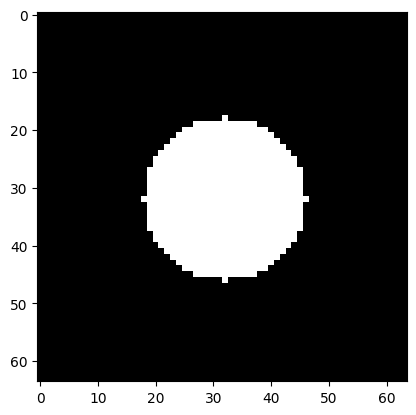

In [7]:

test_img = X[0].reshape(1, 64, 64, 3)
prediction = model.predict(test_img)
classes = ['دائرة (Circle)', 'مربع (Square)', 'مثلث (Triangle)']

print(f"الموديل بيقول إن الصورة دي: {classes[np.argmax(prediction)]}")
plt.imshow(X[0])
plt.show()